<a href="https://colab.research.google.com/github/RajManish8340/micro-gradient-descent/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
  return x**2 + 7


In [4]:
f(3)

16

[907 848 791 736 683 632 583 536 491 448 407 368 331 296 263 232 203 176
 151 128 107  88  71  56  43  32  23  16  11   8   7   8  11  16  23  32
  43  56  71  88 107 128 151 176 203 232 263 296 331 368 407 448 491 536
 583 632 683 736 791 848]
(60,)


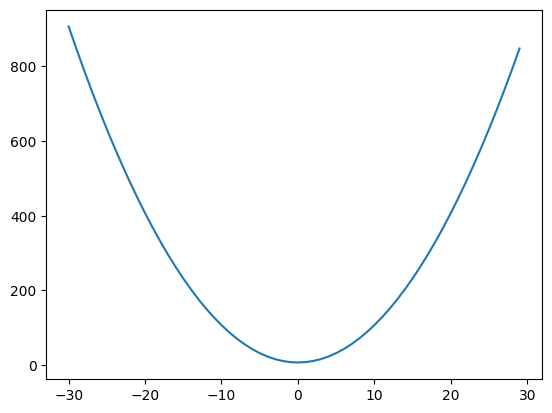

In [5]:
xs = np.arange(-30, 30, 1)
ys = f(xs)
print(ys)
print(ys.shape)

plt.plot(xs, ys)
plt.show()

In [6]:
h = 0.000001
x = 3

(f(x + h) - f(x))/h  # this is the differentiating the function wrt x i.e 2x


6.000001000927568

In [7]:
h = 0.0001

a = 3
b = -5
c = 8

d1 = b*c + a
a += h
d2 = b*c + a

print("d1", d1)
print("d2", d2)
print("derivative wrt a", (d2 - d1)/h) # derivate of the function wrt a is 1

d1 -37
d2 -36.9999
derivative wrt a 1.0000000000331966


In [14]:
class Value:

   # chldren is a tuple not a set as it could cause bugs if the both self and other are same
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.prev = set(_children) # converts tuple into a set (just the prev operands of current)
    self.label = label
    self.grad = 0
    self.backward = lambda: None
    self._op = _op

  def __repr__(self):
    return (f"Value(data={self.data})")

  def __add__(self, other):
    # this is for if there is something like other.__init__(self),
    # so the functions are also valid for the other if it is not a Value
    # we are making it one Value(other)
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1*out.grad
      other.grad += 1*out.grad
    out.backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out.backward = _backward

    return out

  def __pow__(self, other):
    # only support for int and float powers
    # stop the program and give error if not so
    assert isinstance(other, (int, float))
    # here other is not a Value object so we do not need other.data
    # its stricly int or float
    out = Value(self.data ** other, (self, other), f'**{other}')

    def _backward():
      self.grad += other.data * (self.data**other.data-1) * out.grad
    out.backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self, other):
    return self * -1

  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    return self + (-other)

  def __tanh__(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x + 1))
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out.backward = _backward

    return out

  def __exp__(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out.backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1
    for node in reversed(topo):
      node._backward()

